(02-08-capm)=

# Het CAPM

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1961–1973.

**Wat we al weten.** Uit [](#01-04-markowitz) weten we welke portefeuille één
mean-variance-belegger zou moeten houden: een mengsel van de risicovrije rente en
één tangentportefeuille, die voor iedereen dezelfde is. De CRSP-tape
([](#02-05-crsp-tape)) maakte het mogelijk om te meten wat "de markt" deed, en de
event study ([](#02-07-event-studies)) gebruikte het marktmodel om een "normaal"
rendement van een abnormaal rendement te scheiden. Maar dat marktmodel is een
statistische regressie zonder economische inhoud: het zegt niet welk verwacht
rendement bij welk aandeel *hoort*.

**Welke vraag staat open.** Als iedereen doet wat Markowitz voorschrijft en de
markt moet ruimen, welk verwacht rendement hoort dan bij welk risico?
```

## Overzicht

Tussen 1961 en 1966 schreven vier mensen, grotendeels onafhankelijk van elkaar,
hetzelfde model op. Jack Treynor, een consultant bij Arthur D. Little, liet in
1961 en 1962 manuscripten circuleren die pas decennia later werden gepubliceerd
{cite}`Treynor1961,Treynor1962`. William Sharpe, die zijn proefschrift onder informele begeleiding van Markowitz
schreef, publiceerde
in 1964 in *The Journal of Finance* {cite}`Sharpe1964`; John Lintner in 1965 in
*The Review of Economics and Statistics* {cite}`Lintner1965`; Jan Mossin in 1966
in *Econometrica* {cite}`Mossin1966`. Het resultaat heet sindsdien het *Capital
Asset Pricing Model* (CAPM), en het is de eerste theorie in deze reeks die niet
zegt wat een belegger zou moeten doen, maar wat prijzen *zijn*.

Het CAPM definieert het tijdvak omdat het de overgang markeert van
beslissingstheorie naar evenwichtstheorie, met een scherpe, falsifieerbare
voorspelling: verwachte excess rendementen zijn evenredig met één getal, de bèta,
en met niets anders. Dat is motief 3 in zijn zuiverste vorm — een *theorie met
tests*. Jensen maakte van de afstand tot de theorie een prestatiemaatstaf
{cite}`Jensen1968`, Black liet zien wat er overblijft als lenen niet vrij is
{cite}`Black1972`, en twee empirische papers legden de methodologie vast die het
vak tot vandaag gebruikt: de tijdreekstoets met op bèta gesorteerde portefeuilles
{cite}`BlackJensenScholes1972` en de cross-sectionele tweestapsmethode
{cite}`FamaMacBeth1973`.

We leiden het CAPM af uit de frontier van [](#01-04-markowitz), daarna de
toetsen, met de valkuil die ze allemaal vormgaf: de bèta is geschat, niet bekend.
Aan het eind repliceren we het centrale empirische feit van dit tijdvak — de
security market line is vlakker dan het CAPM voorspelt, met een intercept boven
de risicovrije rente — in de stijl van Black, Jensen en Scholes op 1931–1965, op
French' bèta-portefeuilles na 1963, en met Fama-MacBeth en GRS op de 25
size/BM-portefeuilles.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Markowitz en Tobin lieten twee dingen zien. Wie alleen om verwachting en risico
geeft en tegen een vaste rente kan lenen, stopt zijn risicovolle geld in één en
hetzelfde mandje, hoe voorzichtig hij ook is; de voorzichtige houdt er weinig van,
de agressieve leent bij. En hoeveel risico een aandeel aan dat mandje toevoegt,
hangt af van hoe sterk het met het mandje meebeweegt.

Het CAPM voegt daar één stap aan toe, en die stap is boekhouding. Als
*iedereen* hetzelfde mandje houdt, houden alle beleggers samen ook dat mandje.
Maar wat alle beleggers samen houden, is alles wat er te koop is. Het mandje dat
iedereen wil, moet dus de samenstelling van de hele markt hebben. Wil iedereen
relatief meer van een aandeel dan er bestaat, dan stijgt zijn prijs en daalt zijn
verwachte rendement, tot vraag en aanbod elkaar raken.

Combineer dat met het tweede inzicht. In de optimale portefeuille levert elk
aandeel per eenheid toegevoegd risico hetzelfde extra rendement op — anders zou de
belegger er meer of minder van kopen. Het toegevoegde risico is de meebeweging met
de portefeuille, en die portefeuille is de markt. Het verwachte extra rendement
van een aandeel is dus evenredig met zijn meebeweging met de markt, geschaald
zodat de markt zelf op één uitkomt: de *bèta*.

Twee consequenties maken het model tot wat het is. Het bedrijfsspecifieke
risico van een aandeel levert geen enkele beloning op, hoe groot het ook is: wie
het draagt, had het gratis kunnen wegdiversifiëren. En er is één prijs van risico
voor de hele markt, de marktpremie: elk aandeel, fonds of project krijgt dezelfde
beloning per eenheid bèta. Daarmee wordt het CAPM een instrument — voor de
kostenvoet van vermogen, voor de beoordeling van een fondsbeheerder, en voor het
"normale" rendement in een event study.

Omdat de voorspelling zo scherp is, is ze te toetsen: gemiddelde rendementen
tegen bèta moeten op één rechte liggen, door de risicovrije rente en door de markt
bij bèta één — de *security market line*. De empirische geschiedenis van dit
tijdvak is de vraag waarom de punten er niet precies op liggen.

## Toy-voorbeeld: drie activa, twee beleggers

We nemen de drie activa uit het toy-voorbeeld van [](#01-04-markowitz), maar
draaien de redenering om. Daar waren de verwachte rendementen gegeven en zochten
we de optimale portefeuille. Hier zijn het *aanbod* en de *beleggers* gegeven, en
zoeken we de verwachte rendementen die de markt doen ruimen.

**De markt.** Er zijn drie risicovolle activa met een totale marktwaarde van 900:

| Activum | marktwaarde | marktgewicht $w_{m,i}$ | $\sigma_i$ |
|---|---|---|---|
| A (aandelen) | 300 | 1/3 | 20% |
| B (kleine aandelen) | 200 | 2/9 | 30% |
| C (obligaties) | 400 | 4/9 | 10% |

met dezelfde covariantiematrix als in L4 ($\sigma_{AB} = 0{,}02$, C ongecorreleerd)
en een risicovrije rente van $R^{f} - 1 = 2\%$. Het risicovrije activum is in
*nul netto aanbod*: wat de een uitleent, leent de ander.

**De beleggers.** Belegger 1 is agressief: vermogen $W_1 = 150$ en risicoaversie
$\gamma_1 = 2$. Belegger 2 is voorzichtig: $W_2 = 750$ en $\gamma_2 = 6$. Elke
belegger kiest de fracties $\mathbf{a}_k$ van zijn vermogen in de drie activa om
$\mathbf{a}_k'\boldsymbol{\mu}^{e} - \tfrac{\gamma_k}{2}\,\mathbf{a}_k'\boldsymbol{\Sigma}\mathbf{a}_k$
te maximaliseren; de eerste-ordevoorwaarde geeft
$\mathbf{a}_k = \gamma_k^{-1}\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e}$.

**Stap 1: marktclearing.** De totale vraag in geld is
$\sum_k W_k \mathbf{a}_k = (150/2 + 750/6)\,\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e}
= 200\,\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e}$. Die moet gelijk zijn aan het
aanbod $900\,\mathbf{w}_m$. Dus

$$
\boldsymbol{\mu}^{e} = \frac{900}{200}\,\boldsymbol{\Sigma}\mathbf{w}_m
= 4{,}5\;\boldsymbol{\Sigma}\mathbf{w}_m .
$$

Het getal $4{,}5$ is de *geaggregeerde* risicoaversie: het vermogensgewogen
harmonisch gemiddelde van $2$ en $6$. Nu rijen maal kolom:

$$
\boldsymbol{\Sigma}\mathbf{w}_m =
\begin{pmatrix}
0{,}04\cdot\tfrac13 + 0{,}02\cdot\tfrac29 \\
0{,}02\cdot\tfrac13 + 0{,}09\cdot\tfrac29 \\
0{,}01\cdot\tfrac49
\end{pmatrix}
=
\begin{pmatrix} 0{,}017778 \\ 0{,}026667 \\ 0{,}004444 \end{pmatrix}
= \frac{1}{225}\begin{pmatrix} 4 \\ 6 \\ 1 \end{pmatrix},
\qquad
\boldsymbol{\mu}^{e} = \begin{pmatrix} 0{,}08 \\ 0{,}12 \\ 0{,}02 \end{pmatrix}.
$$

Met $R^{f} - 1 = 2\%$ zijn de verwachte rendementen dus 10%, 14% en 4% — precies
de getallen die in L4 als gegeven werden verondersteld.

**Stap 2: wat houdt ieder?** Controleer eerst dat
$\boldsymbol{\Sigma}\,(1{,}5;\ 1{,}0;\ 2{,}0)' = (0{,}06 + 0{,}02;\ 0{,}03 + 0{,}09;\ 0{,}02)' = \boldsymbol{\mu}^{e}$,
dus $\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e} = (1{,}5;\ 1{,}0;\ 2{,}0)'$. Dan

| | A | B | C | totaal risicovol | risicovrij |
|---|---|---|---|---|---|
| belegger 1: $\mathbf{a}_1 = \tfrac12(1{,}5;1;2)$ | 0,75 | 0,50 | 1,00 | 2,25 | −1,25 |
| in geld ($\times 150$) | 112,5 | 75 | 150 | 337,5 | −187,5 |
| belegger 2: $\mathbf{a}_2 = \tfrac16(1{,}5;1;2)$ | 0,25 | 0,1667 | 0,3333 | 0,75 | +0,25 |
| in geld ($\times 750$) | 187,5 | 125 | 250 | 562,5 | +187,5 |
| **samen** | **300** | **200** | **400** | **900** | **0** |

Belegger 1 leent 187,5 en belegger 2 leent precies dat bedrag uit. Deel de
risicovolle posities van elk door hun totaal: $(0{,}75;0{,}5;1)/2{,}25$ en
$(0{,}25;\tfrac16;\tfrac13)/0{,}75$ zijn allebei $(\tfrac13, \tfrac29, \tfrac49)$.
Beide beleggers houden de tangentportefeuille uit L4, en die is gelijk aan de
marktportefeuille. Ze verschillen alleen in hoeveel.

**Stap 3: bèta's en de SML.** De marktvariantie is
$\sigma_m^2 = \mathbf{w}_m'\boldsymbol{\Sigma}\mathbf{w}_m
= \tfrac13\cdot\tfrac{4}{225} + \tfrac29\cdot\tfrac{6}{225} + \tfrac49\cdot\tfrac{1}{225}
= \tfrac{28}{2025} = 0{,}013827$, dus $\sigma_m = 11{,}76\%$, en de marktpremie
is $\mu_m^{e} = 4{,}5 \cdot 0{,}013827 = 6{,}222\%$. De bèta's zijn
$\beta_{i,m} = (\boldsymbol{\Sigma}\mathbf{w}_m)_i/\sigma_m^2$:

$$
\beta_{A,m} = \frac{4/225}{28/2025} = \frac{9}{7} = 1{,}2857,\qquad
\beta_{B,m} = \frac{27}{14} = 1{,}9286,\qquad
\beta_{C,m} = \frac{9}{28} = 0{,}3214 .
$$

En inderdaad: $\tfrac97 \cdot 6{,}222\% = 8\%$, $\tfrac{27}{14}\cdot 6{,}222\% = 12\%$,
$\tfrac{9}{28}\cdot 6{,}222\% = 2\%$. Alle drie liggen exact op de security market
line, en het marktgewogen gemiddelde van de bèta's is
$\tfrac13\cdot\tfrac97 + \tfrac29\cdot\tfrac{27}{14} + \tfrac49\cdot\tfrac{9}{28} = \tfrac37+\tfrac37+\tfrac17 = 1$.

Kijk ten slotte naar wát er beloond wordt. Van de variantie van C is
$\beta_{C,m}^2\sigma_m^2 = 0{,}00143$ systematisch en $0{,}00857$ — 86% —
idiosyncratisch; bij A en B is dat 43%. C draagt relatief het meeste eigen risico
en krijgt de laagste premie. Het eigen risico telt eenvoudigweg niet mee.

In [2]:
Sigma = np.array([[0.04, 0.02, 0.00],
                  [0.02, 0.09, 0.00],
                  [0.00, 0.00, 0.01]])
supply = np.array([300.0, 200.0, 400.0])
wealth = np.array([150.0, 750.0])
gamma = np.array([2.0, 6.0])
rf = 0.02

w_m = supply / supply.sum()
gamma_m = supply.sum() / (wealth / gamma).sum()          # aggregate risk aversion
mu_e = gamma_m * Sigma @ w_m                              # market clearing
a = np.outer(1 / gamma, np.linalg.solve(Sigma, mu_e))     # fractions of wealth, per investor
dollars = a * wealth[:, None]

holdings = pd.DataFrame(
    np.column_stack([dollars, dollars.sum(axis=1), wealth - dollars.sum(axis=1)]),
    index=["belegger 1", "belegger 2"],
    columns=["A", "B", "C", "risicovol", "risicovrij"],
)
holdings.loc["samen"] = holdings.sum()
holdings.round(4)

,A,B,C,risicovol,risicovrij
belegger 1,112.5,75.0,150.0,337.5,-187.5
belegger 2,187.5,125.0,250.0,562.5,187.5
samen,300.0,200.0,400.0,900.0,0.0


In [3]:
var_m = w_m @ Sigma @ w_m
beta = Sigma @ w_m / var_m
systematic = beta**2 * var_m

pd.DataFrame(
    {
        "mu^e": mu_e,
        "beta": beta,
        "beta x marktpremie": beta * (w_m @ mu_e),
        "risicovolle mix belegger 1": dollars[0] / dollars[0].sum(),
        "risicovolle mix belegger 2": dollars[1] / dollars[1].sum(),
        "aandeel idiosyncratisch": 1 - systematic / np.diag(Sigma),
    },
    index=["A", "B", "C"],
).round(6)

,mu^e,beta,beta x marktpremie,risicovolle mix belegger 1,risicovolle mix belegger 2,aandeel idiosyncratisch
A,0.08,1.285714,0.08,0.333333,0.333333,0.428571
B,0.12,1.928571,0.12,0.222222,0.222222,0.428571
C,0.02,0.321429,0.02,0.444444,0.444444,0.857143


In [4]:
pd.Series(
    {
        "geaggregeerde risicoaversie": gamma_m,
        "marktvariantie": var_m,
        "marktpremie": w_m @ mu_e,
        "gamma_m x marktvariantie": gamma_m * var_m,
        "marktgewogen bèta": w_m @ beta,
        "Sharpe-ratio markt": (w_m @ mu_e) / np.sqrt(var_m),
    }
).round(6)

geaggregeerde risicoaversie    4.500000
marktvariantie                 0.013827
marktpremie                    0.062222
gamma_m x marktvariantie       0.062222
marktgewogen bèta              1.000000
Sharpe-ratio markt             0.529150
dtype: float64

De code geeft dezelfde getallen als de handberekening: holdings van
$(112{,}5;\ 75;\ 150)$ en $(187{,}5;\ 125;\ 250)$ die optellen tot het aanbod,
een risicovrije positie die optelt tot nul, twee identieke risicovolle mixen
$(0{,}3333;\ 0{,}2222;\ 0{,}4444)$, bèta's $(1{,}2857;\ 1{,}9286;\ 0{,}3214)$ en
een marktpremie van $0{,}062222 = 4{,}5 \times 0{,}013827$.

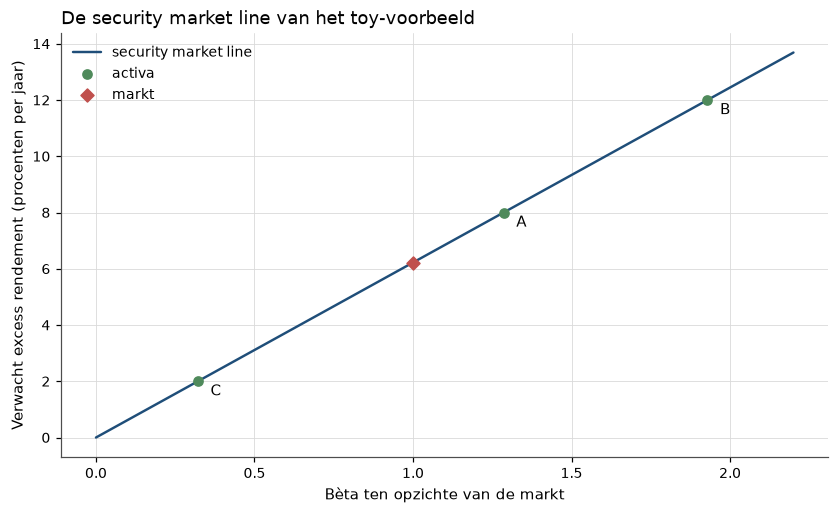

In [5]:
grid = np.linspace(0, 2.2, 50)
fig, ax = plt.subplots()
ax.plot(grid, 100 * grid * (w_m @ mu_e), lw=1.6, label="security market line")
ax.scatter(beta, 100 * mu_e, zorder=3, color=hap.plotting.COLORS[2], label="activa")
ax.scatter([1.0], [100 * (w_m @ mu_e)], marker="D", zorder=3,
           color=hap.plotting.COLORS[1], label="markt")
for name, b, m in zip(["A", "B", "C"], beta, mu_e):
    ax.annotate(name, (b + 0.04, 100 * m - 0.5))
ax.set_xlabel("Bèta ten opzichte van de markt")
ax.set_ylabel("Verwacht excess rendement (procenten per jaar)")
ax.set_title("De security market line van het toy-voorbeeld")
ax.legend()
plt.show()

:::{figure} #cel-capm-toy
:label: fig-capm-toy
:width: 80%

De drie activa uit het toy-voorbeeld liggen exact op één rechte door de oorsprong
en de markt. C had in L4 de slechtste Sharpe-ratio (0,20 tegen 0,40 voor A en B); in het
$(\beta,\mu)$-vlak is dat verschil verdwenen, want idiosyncratisch risico wordt
niet beprijsd.
:::

## Theorie

### Opzet en aannames

Er is één periode, van $t$ naar $t+1$. Er zijn $N$ risicovolle activa met bruto
rendementen $\mathbf{R}_{t+1}$, verwachting $\boldsymbol{\mu}$ en positief
definiete covariantiematrix $\boldsymbol{\Sigma}$, en een risicovrij activum met
bruto rendement $R^{f}$. Excess rendementen zijn
$\mathbf{R}^{e} = \mathbf{R} - R^{f}\mathbf{1}$ met verwachting
$\boldsymbol{\mu}^{e}$. Het aanbod van de risicovolle activa is vast, met
marktwaarden $\mathbf{V}$ en marktgewichten $\mathbf{w}_m = \mathbf{V}/\mathbf{1}'\mathbf{V}$;
het risicovrije activum is in nul netto aanbod. Er zijn $K$ beleggers
$k = 1,\dots,K$ met vermogen $W_k$. We veronderstellen:

1. **Mean-variance.** Elke belegger geeft alleen om de verwachting en de
   variantie van zijn vermogen op $t+1$, en heeft liever meer verwachting en
   minder variantie.
2. **Homogene verwachtingen.** Alle beleggers kennen dezelfde $\boldsymbol{\mu}$
   en $\boldsymbol{\Sigma}$.
3. **Vrij lenen en uitlenen** tegen $R^{f}$, zonder limiet.
4. **Geen frictie.** Geen belastingen, transactiekosten of short-restricties;
   activa zijn oneindig deelbaar en beleggers zijn prijsnemers.

Zolang de payoffs vastliggen, bepaalt de prijs $p_t$ het verwachte rendement
$\E[x_{t+1}]/p_t$. Sharpe, Lintner en Mossin gebruikten elk een andere notatie; wij
vertalen naar die van deze reeks.

### Van tangentportefeuille naar marktportefeuille

*Waarom zou dit waar zijn?* Met een risicovrij activum houdt elke
mean-variance-belegger de tangentportefeuille (de separatiestelling uit
[](#01-04-markowitz)), dus is de som van alle holdings een veelvoud ervan. Die som
is ook het totale aanbod: elk aandeel moet door iemand worden gehouden. Na
normalisatie is de tangentportefeuille dus de marktportefeuille, en wat haar
bijzonder maakt — elk activum levert evenveel rendement per eenheid marginaal
risico — geldt daarmee voor de markt.

:::{prf:theorem} CAPM (Sharpe–Lintner–Mossin)
:label: thm-capm-capm

Onder aannames 1–4 is in evenwicht de marktportefeuille $\mathbf{w}_m$ gelijk aan
de tangentportefeuille, en geldt voor elk activum $i$

```{math}
:label: eq-capm-sml
\E\!\left[R_i\right] - R^{f} = \beta_{i,m}\left(\E\!\left[R_m\right] - R^{f}\right),
\qquad
\beta_{i,m} = \frac{\Cov(R_i, R_m)}{\Var(R_m)} .
```
:::

:::{prf:proof}
*Stap 1: iedereen houdt de tangentportefeuille.* Volgens de separatiestelling
({prf:ref}`cor-markowitz-separatie`) houdt belegger $k$ een fractie $a_k$ van
zijn vermogen in $\mathbf{w}_{\mathrm{tan}}$ en $1 - a_k$ in het risicovrije
activum, waarbij
$\mathbf{w}_{\mathrm{tan}} = \boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e}/(\mathbf{1}'\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e})$
voor alle beleggers dezelfde is, omdat ze dezelfde $\boldsymbol{\mu}$ en
$\boldsymbol{\Sigma}$ zien (aanname 2).

*Stap 2: marktclearing.* De vraag naar risicovolle activa in geld is
$\sum_k W_k a_k \mathbf{w}_{\mathrm{tan}}$, het aanbod is
$\mathbf{V} = (\mathbf{1}'\mathbf{V})\,\mathbf{w}_m$. Gelijkstellen geeft
$\mathbf{w}_m = c\,\mathbf{w}_{\mathrm{tan}}$ met
$c = \sum_k W_k a_k / \mathbf{1}'\mathbf{V}$. Omdat
$\mathbf{1}'\mathbf{w}_m = \mathbf{1}'\mathbf{w}_{\mathrm{tan}} = 1$ is $c = 1$,
dus $\mathbf{w}_m = \mathbf{w}_{\mathrm{tan}}$. (Dat $c = 1$ is ook precies de
voorwaarde dat het risicovrije activum ruimt:
$\sum_k W_k(1-a_k) = 0$ als $\sum_k W_k = \mathbf{1}'\mathbf{V}$.)

*Stap 3: de eerste-ordevoorwaarde van de markt.* Uit de uitdrukking voor
$\mathbf{w}_{\mathrm{tan}}$ volgt
$\boldsymbol{\Sigma}\mathbf{w}_m = \kappa\,\boldsymbol{\mu}^{e}$ met
$\kappa = 1/(\mathbf{1}'\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e})$. De $i$-de rij
van $\boldsymbol{\Sigma}\mathbf{w}_m$ is $\Cov(R_i, R_m)$, dus

$$
\Cov(R_i, R_m) = \kappa\,\mu_i^{e} \qquad \text{voor elke } i .
$$

*Stap 4: de constante vastleggen.* Vermenigvuldig beide kanten van
$\boldsymbol{\Sigma}\mathbf{w}_m = \kappa\boldsymbol{\mu}^{e}$ met $\mathbf{w}_m'$:
$\sigma_m^2 = \kappa\,\mu_m^{e}$, dus $\kappa = \sigma_m^2/\mu_m^{e}$. Invullen in
stap 3 en delen door $\kappa$ geeft
$\mu_i^{e} = \Cov(R_i,R_m)\,\mu_m^{e}/\sigma_m^2 = \beta_{i,m}\,\mu_m^{e}$. $\square$
:::

De stelling zegt meer dan de formule laat zien. De marktpremie zelf is geen vrije
parameter maar een evenwichtsuitkomst. Stel dat belegger $k$ de
mean-variance-doelfunctie van het toy-voorbeeld heeft, zodat zijn risicovolle
fracties $\mathbf{a}_k = \gamma_k^{-1}\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e}$
zijn. Marktclearing geeft dan
$\boldsymbol{\mu}^{e} = \gamma_m\,\boldsymbol{\Sigma}\mathbf{w}_m$ met

```{math}
:label: eq-capm-premie
\frac{1}{\gamma_m} = \sum_k \frac{W_k}{W}\,\frac{1}{\gamma_k},
\qquad
\mu_m^{e} = \gamma_m\,\sigma_m^2 .
```

De marktpremie is de geaggregeerde risicoaversie maal de hoeveelheid risico in de
markt. Met een marktvolatiliteit van ruwweg 20% en een premie van ruwweg 6% per
jaar is $\gamma_m \approx 0{,}06/0{,}04 = 1{,}5$ — onschuldig, tot we in
[](#03-13-equity-premium-puzzle) de premie aan de volatiliteit van *consumptie*
koppelen.

### De bèta-representatie en wat ze eigenlijk zegt

*Waarom zou dit waar zijn?* Het bewijs van {prf:ref}`thm-capm-capm` gebruikte
evenwicht alleen om te concluderen dat de markt de tangentportefeuille is; stap 3
en 4 zijn pure meetkunde. De lineaire relatie gaat dus over efficiëntie, niet over
evenwicht.

:::{prf:proposition} Bèta-representatie en efficiëntie
:label: prop-capm-beta

Laat $p$ een portefeuille zijn met $\mu_p^{e} \neq 0$ en
$\beta_{i,p} = \Cov(R_i, R_p)/\Var(R_p)$. Dan geldt
$\mu_i^{e} = \beta_{i,p}\,\mu_p^{e}$ voor alle $i$ dan en slechts dan als $p$ de
tangentportefeuille is.
:::

:::{prf:proof}
"Als": stap 3 en 4 van het bewijs hierboven, met $p$ in de rol van $m$. "Alleen
als": stapel de $N$ relaties tot
$\boldsymbol{\mu}^{e} = \boldsymbol{\Sigma}\mathbf{w}_p\,\mu_p^{e}/\sigma_p^2$,
want $\Cov(\mathbf{R}, R_p) = \boldsymbol{\Sigma}\mathbf{w}_p$. Dan is
$\mathbf{w}_p = (\sigma_p^2/\mu_p^{e})\,\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e}$,
evenredig met de tangentportefeuille; normalisatie
$\mathbf{1}'\mathbf{w}_p = 1$ legt de evenredigheidsconstante vast. $\square$
:::

Een toets van [](#eq-capm-sml) is dus een toets van één uitspraak: *de
marktportefeuille is mean-variance-efficiënt*. Maar "de marktportefeuille" is in
de theorie de portefeuille van álle risicovolle activa, inclusief vastgoed en
menselijk kapitaal, en in de toetsen een aandelenindex. Wat dat voor de
toetsbaarheid betekent, is het onderwerp van [](#03-14-roll); hier nemen we de
index als de markt.

In de taal van [](#05-26-sdf-unificatie) is dit equivalent met een *stochastic
discount factor* (SDF: de willekeurige variabele waarmee payoffs worden
verdisconteerd) die lineair is in het marktrendement, $m_{t+1} = a - b\,R_{m,t+1}$.

### Prestatiematen: Sharpe en Treynor

Een individueel aandeel ligt op de SML maar rechts van de kapitaalmarktlijn
$\E[R_p] = R^{f} + S_m\,\sigma_p$ uit L4: met
$\sigma_i^2 = \beta_{i,m}^2\sigma_m^2 + \sigma^2_{\varepsilon,i}$ ligt het
$\sigma_i - \beta_{i,m}\sigma_m$ te ver naar rechts, precies door idiosyncratisch
risico. Bij de twee lijnen horen twee prestatiematen. {cite:t}`Sharpe1966` beoordeelde 34
beleggingsfondsen over 1954–1963 met de verhouding $\mu_p^{e}/\sigma_p$ — hij
noemde haar *reward-to-variability*; sindsdien heet ze de Sharpe-ratio. Elf van de
34 fondsen haalden na kosten een hogere ratio dan de Dow Jones-index, 23 een
lagere. Die maatstaf is de
juiste voor een belegger die het fonds als zijn hele portefeuille houdt, want dan
is totaal risico relevant. Treynor stelde voor om te delen door de bèta, de
juiste maatstaf voor een fonds dat één onderdeel is van een gespreide
portefeuille. {cite:t}`Jensen1968` maakte er een regressie van, en die vorm is
blijven hangen.

### Jensens alfa en de tijdreekstoets

*Waarom zou dit waar zijn?* Regresseer het excess rendement van een activum op
het excess marktrendement: de helling schat de bèta, het intercept wat er
*overblijft* na de beloning voor bèta. Het CAPM zegt dat dat nul is; een positief
intercept is vakmanschap of een fout in de theorie.

De regressie is

```{math}
:label: eq-capm-tijdreeks
R^{e}_{i,t+1} = \alpha_i + \beta_{i,m}\,R^{e}_{m,t+1} + \varepsilon_{i,t+1},
\qquad \E[\varepsilon_{i,t+1}] = 0,\ \Cov(\varepsilon_{i,t+1}, R^{e}_{m,t+1}) = 0 .
```

Neem verwachtingen: $\mu_i^{e} = \alpha_i + \beta_{i,m}\mu_m^{e}$. Het CAPM is dus
equivalent met $\alpha_i = 0$ voor alle $i$, en $\alpha_i$ — *Jensens alfa* — is
de verticale afstand van activum $i$ tot de SML. Merk op dat de regressie
[](#eq-capm-tijdreeks) altijd kan worden gedraaid; het is het marktmodel uit
[](#02-07-event-studies). Wat het CAPM toevoegt, is één restrictie op het
intercept. Jensen paste haar toe op 115 beleggingsfondsen met jaardata over 1945–1964 en
vond een gemiddelde alfa van −1,1% per jaar na kosten en −0,4% vóór
beheerkosten; slechts drie fondsen hadden een significant positieve alfa (zijn
tabellen 2 en 4) {cite}`Jensen1968`; zijn
paper is de stamvader van de hele literatuur over actief beheer, en we komen erop
terug in [](#04-25-industrie).

Voor één activum is de toets een gewone $t$-toets op $\hat\alpha_i$. Voor $N$
activa tegelijk wil men $H_0: \boldsymbol{\alpha} = \mathbf{0}$ gezamenlijk
toetsen, en omdat de residuen van verschillende portefeuilles sterk gecorreleerd
zijn, is het niet genoeg om $N$ afzonderlijke $t$-waarden te bekijken.
{cite:t}`GibbonsRossShanken1989` gaven de exacte eindige-steekproeftoets.

:::{prf:theorem} GRS-toets
:label: thm-capm-grs

Laat $\hat{\boldsymbol{\alpha}}$ de OLS-intercepten zijn uit [](#eq-capm-tijdreeks)
voor $N$ activa over $T$ perioden, $\hat{\boldsymbol{\Sigma}}$ de
ML-schatter van de residucovariantiematrix, en $\hat\mu_m^{e}$, $\hat\sigma_m$ het
steekproefgemiddelde en de ML-standaarddeviatie van de factor. Als de residuen
onafhankelijk en normaal verdeeld zijn, gegeven de factor, dan geldt onder
$H_0: \boldsymbol{\alpha} = \mathbf{0}$

```{math}
:label: eq-capm-grs
\mathrm{GRS} = \frac{T-N-1}{N}\;
\frac{\hat{\boldsymbol{\alpha}}'\hat{\boldsymbol{\Sigma}}^{-1}\hat{\boldsymbol{\alpha}}}
{1 + \left(\hat\mu_m^{e}/\hat\sigma_m\right)^2}
\;\sim\; F(N,\ T-N-1) .
```

Bovendien is
$\hat{\boldsymbol{\alpha}}'\hat{\boldsymbol{\Sigma}}^{-1}\hat{\boldsymbol{\alpha}} = \hat S_q^2 - \hat S_m^2$,
met $\hat S_q$ de maximale in-sample Sharpe-ratio van de $N$ activa samen met de
markt en $\hat S_m$ die van de markt alleen.
:::

:::{prf:proof}
:class: dropdown

We bewijzen de meetkundige identiteit; voor de $F$-verdeling (een Hotelling-$T^2$,
omdat $\hat{\boldsymbol{\alpha}}$ gegeven de factor normaal is en onafhankelijk van
de Wishart-verdeelde $T\hat{\boldsymbol{\Sigma}}$) verwijzen we naar
{cite:t}`GibbonsRossShanken1989`. Het idee: de maximale Sharpe-ratio hangt alleen
af van de *ruimte* van portefeuilles, niet van de basis waarin we die beschrijven;
kies een basis waarin markt en rest ongecorreleerd zijn, en de kwadraten tellen op.

Neem de $N+1$ excess rendementen $(R^{e}_m, R^{e}_1, \dots, R^{e}_N)$. Vervang
elke $R^{e}_i$ door $e_i = R^{e}_i - \hat\beta_{i,m}R^{e}_m$. Dat is een
inverteerbare lineaire transformatie (een driehoeksmatrix met enen op de
diagonaal), dus de verzameling haalbare excess-rendementsportefeuilles, en
daarmee de maximale Sharpe-ratio, verandert niet. In de steekproef heeft $e_i$
gemiddelde $\hat\alpha_i$ en is het, per constructie van OLS, ongecorreleerd met
$R^{e}_m$; de covariantiematrix van $(e_1,\dots,e_N)$ is $\hat{\boldsymbol{\Sigma}}$.
De covariantiematrix van $(R^{e}_m, \mathbf{e})$ is dus blokdiagonaal,
$\mathrm{diag}(\hat\sigma_m^2, \hat{\boldsymbol{\Sigma}})$, en de maximale
kwadratische Sharpe-ratio $\hat{\boldsymbol{\mu}}'\hat{\mathbf{V}}^{-1}\hat{\boldsymbol{\mu}}$
([](#eq-markowitz-tangent)) valt uiteen in

$$
\hat S_q^2 = \frac{(\hat\mu^{e}_m)^2}{\hat\sigma_m^2}
+ \hat{\boldsymbol{\alpha}}'\hat{\boldsymbol{\Sigma}}^{-1}\hat{\boldsymbol{\alpha}}
= \hat S_m^2 + \hat{\boldsymbol{\alpha}}'\hat{\boldsymbol{\Sigma}}^{-1}\hat{\boldsymbol{\alpha}} . \qquad \square
$$
:::

{cite:t}`GibbonsRossShanken1989` schrijven de statistiek met de zuivere
schatter van $\boldsymbol{\Sigma}$ en een factor $T(T-N-1)/(N(T-2))$; dat is
algebraïsch hetzelfde als [](#eq-capm-grs) met de ML-schatter.

De identiteit sluit rechtstreeks aan op {prf:ref}`prop-capm-beta`: GRS vraagt of
de markt significant *onder* de frontier van de testactiva ligt. Een verwerping
zegt dus niet "bèta doet er niet toe", maar "er is een portefeuille van deze
activa die de markt verslaat".

### De cross-sectionele toets: Fama en MacBeth

*Waarom zou dit waar zijn?* De tijdreekstoets kijkt naar intercepten, niet naar
de *helling*: is de beloning per eenheid bèta gelijk aan de marktpremie?
Regresseer daarom gemiddelde rendementen op bèta's. Het probleem is inferentie:
rendementen van aandelen in dezelfde maand zijn sterk gecorreleerd, dus een
gewone OLS-standaardfout in de cross-sectie is veel te klein. Fama en MacBeth
draaiden de cross-sectie *elke maand opnieuw* en behandelden de hellingen als
tijdreeks.

De procedure heeft twee stappen. Eerst worden de bèta's $\hat\beta_{i,m}$ geschat
uit tijdreeksregressies. Dan wordt voor elke periode $t$ de cross-sectionele
regressie

```{math}
:label: eq-capm-fm
R^{e}_{i,t+1} = \gamma_{0,t+1} + \gamma_{1,t+1}\,\hat\beta_{i,m} + \eta_{i,t+1},
\qquad i = 1,\dots,N,
```

gedraaid, wat een tijdreeks van schattingen $(\hat\gamma_{0,t}, \hat\gamma_{1,t})$
oplevert. De schatters en hun standaardfouten zijn

$$
\bar\gamma_j = \frac1T\sum_{t=1}^{T}\hat\gamma_{j,t},
\qquad
\widehat{\SD}(\bar\gamma_j) = \frac{1}{\sqrt{T}}
\sqrt{\frac{1}{T-1}\sum_{t=1}^{T}\left(\hat\gamma_{j,t} - \bar\gamma_j\right)^2} .
$$

Het CAPM voorspelt $\gamma_0 = 0$ (in excess rendementen; Fama en MacBeth
gebruikten bruto rendementen en toetsten $\gamma_0 = R^{f}$) en
$\gamma_1 = \mu_m^{e} > 0$. Waarom werkt de standaardfout ondanks de
cross-sectionele correlatie? Omdat $\hat\gamma_{j,t}$ een lineaire combinatie van
de rendementen van periode $t$ is: de $j$-de rij van
$(\mathbf{X}'\mathbf{X})^{-1}\mathbf{X}'$, met $\mathbf{X} = [\mathbf{1},\hat{\boldsymbol{\beta}}]$,
is een vector van portefeuillegewichten. $\hat\gamma_{1,t}$ is dus het rendement
van een portefeuille met bèta één en gewichtensom nul, en $\bar\gamma_1$ is het
gemiddelde rendement van die portefeuille. De variantie van dat gemiddelde meet
u met de tijdreeks van de portefeuille, en alle correlatie tussen aandelen zit daar
automatisch in. Zolang de rendementen niet in de tijd gecorreleerd zijn, is de
Fama-MacBeth-standaardfout correct; zijn ze dat wel, dan vervangt u haar door een
Newey-West-standaardfout op dezelfde tijdreeks.

Fama en MacBeth voegden in [](#eq-capm-fm) nog twee regressoren toe:
$\hat\beta^2_{i,m}$, om te toetsen of de relatie lineair is, en de residuele
standaarddeviatie $s(\hat\varepsilon_i)$, om te toetsen of idiosyncratisch risico
wordt beloond. Het CAPM voorspelt dat beide coëfficiënten nul zijn.

```{admonition} De eerste stap is ook een schatting
:class: warning

De standaardfout van Fama en MacBeth behandelt $\hat{\boldsymbol{\beta}}$ alsof het
de ware $\boldsymbol{\beta}$ is. {cite:t}`Shanken1992` liet zien dat ze daardoor te
klein is, en gaf de correctie. Met één factor en een factorpremie $\lambda$ (hier
$\bar\gamma_1$) is de gecorrigeerde variantie

$$
\widehat{\Var}_{\mathrm{S}}(\bar{\boldsymbol{\gamma}})
= (1 + c)\left(\widehat{\Var}_{\mathrm{FM}}(\bar{\boldsymbol{\gamma}}) - \frac{\boldsymbol{\Sigma}_f^{*}}{T}\right)
+ \frac{\boldsymbol{\Sigma}_f^{*}}{T},
\qquad c = \frac{\lambda^2}{\sigma^2_m},
$$

met $\boldsymbol{\Sigma}_f^{*}$ de factorvariantie "omrand" met nullen voor het
intercept. De factor $c$ is het kwadraat van de Sharpe-ratio van de factor. Bij
een verhandelbare marktfactor met maanddata is dat klein, $(0{,}6/4{,}5)^2 \approx 0{,}02$;
bij niet-verhandelbare factoren met een grote geschatte premie kan zij aanzienlijk
zijn — Shanken rekent een voorbeeld door met $c = 0{,}36$.
```

### Errors-in-variables, en waarom portefeuilles

*Waarom zou dit waar zijn?* Een geschatte bèta is de ware bèta plus ruis — het
*errors-in-variables*-probleem (meetfout in een verklarende variabele). Wie
gemiddelde rendementen op geschatte bèta's regresseert, verklaart dus met een
variabele die deels ruis is, en ruis verklaart niets. De regressie "ziet" daardoor
een zwakkere samenhang dan er is: de helling wordt naar nul getrokken, en omdat
de lijn nog steeds door het gemiddelde punt moet gaan, schuift het intercept
omhoog. Dat is precies het patroon — te vlakke lijn, te hoog intercept — dat de
eerste toetsen op individuele aandelen vonden. De vraag die het tijdvak
beheerste, was of dat patroon in de *economie* zat of in de *econometrie*.

:::{prf:proposition} Attenuatie door geschatte bèta's
:label: prop-capm-eiv

Laat de ware verwachte excess rendementen voldoen aan
$\mu_i^{e} = \gamma_0 + \gamma_1\beta_i$, en laat $\hat\beta_i = \beta_i + u_i$ met
$u_i$ onafhankelijk van $\beta_i$, gemiddelde nul en variantie $\sigma_u^2$. Laat
$\beta_i$ over de cross-sectie gemiddelde $\bar\beta$ en variantie
$\sigma_\beta^2$ hebben. Dan geldt voor de cross-sectionele OLS-regressie van
$\mu_i^{e}$ op $\hat\beta_i$, als $N \to \infty$,

```{math}
:label: eq-capm-eiv
\plim \hat\gamma_1 = \kappa\,\gamma_1,
\qquad
\plim \hat\gamma_0 = \gamma_0 + (1-\kappa)\,\gamma_1\bar\beta,
\qquad
\kappa = \frac{\sigma_\beta^2}{\sigma_\beta^2 + \sigma_u^2} .
```
:::

:::{prf:proof}
De OLS-helling is de steekproefcovariantie van $\mu^{e}_i$ en $\hat\beta_i$ gedeeld
door de steekproefvariantie van $\hat\beta_i$. Door de wet van de grote aantallen
convergeert de teller naar
$\Cov(\gamma_0 + \gamma_1\beta_i,\ \beta_i + u_i) = \gamma_1\sigma_\beta^2$, want $u_i$
is onafhankelijk van $\beta_i$; de noemer convergeert naar
$\sigma_\beta^2 + \sigma_u^2$. Dat geeft de helling. Het OLS-intercept is
$\bar\mu^{e} - \hat\gamma_1\bar{\hat\beta}$, en met
$\bar\mu^{e} \to \gamma_0 + \gamma_1\bar\beta$ en $\bar{\hat\beta} \to \bar\beta$
volgt $\gamma_0 + \gamma_1\bar\beta - \kappa\gamma_1\bar\beta$. $\square$
:::

Hoe groot is dat? De OLS-bèta uit $T$ maanden heeft meetfoutvariantie
$\sigma_u^2 \approx \sigma^2_{\varepsilon}/(T\sigma_m^2)$. Met 10% idiosyncratische
en 4,5% marktvolatiliteit per maand en vijf jaar data is $\sigma_u^2 = 0{,}082$;
bij een spreiding in ware bèta's van 0,30 is $\kappa = 0{,}52$. De helling halveert,
en met $\bar\beta = 1$ en een premie van 0,6% per maand staat het intercept 3,4%
per jaar te hoog — zonder dat er iets mis is met het CAPM.

Dat was de kern van de analyse van {cite:t}`MillerScholes1972`. De eerste toetsen
op individuele aandelen, halverwege de jaren zestig, vonden een te vlakke lijn, een
te hoog intercept en een positief verband met residuele variantie; Miller en
Scholes lieten zien dat meetfouten in bèta zo'n patroon kunnen voortbrengen zonder
dat het model onjuist is. Hun eigen getallen hebben we niet in de primaire bron
kunnen verifiëren; we noemen ze daarom niet.

De remedie is de reden dat asset pricing tot vandaag met portefeuilles werkt.
In een portefeuille van $n$ aandelen heeft de meetfout variantie ongeveer
$\sigma_u^2/n$, omdat de idiosyncratische schokken wegdiversifiëren; bij $n = 50$
is $\kappa = 0{,}09/(0{,}09 + 0{,}0016) = 0{,}98$. Maar willekeurig groeperen gooit
ook de spreiding in ware bèta's weg. Daarom sorteerden Black, Jensen en Scholes op
*geschatte* bèta: de portefeuilles verschillen dan zo veel mogelijk in ware bèta en
zo weinig mogelijk in ruis.

Eén valkuil blijft: wie sorteert op bèta's uit dezelfde periode als waarin hij
toetst, stopt aandelen met toevallig grote $u_i$ in de hoogste groep, en hun bèta
valt daarna terug. BJS sorteerden daarom op bèta's uit de *voorgaande* vijf jaar
(*pre-ranking* bèta's). Fama en MacBeth scheidden drie vensters: twintig
portefeuilles gevormd op zeven jaar data, bèta's geschat op de vijf jaar daarna,
getoetst op de vier jaar daarna.

### Black: het CAPM zonder vrij lenen

*Waarom zou dit waar zijn?* Aanname 3 is de zwakste: bijna niemand kan onbeperkt
lenen tegen de schatkistrente. Beleggers die meer risico willen dan de markt,
kopen dan geen markt met geleend geld maar aandelen met een hoge bèta. Die vraag
drijft de prijzen van hoge-bèta-aandelen op en hun verwachte rendement omlaag. De
SML wordt vlakker en haar intercept komt boven de risicovrije rente te liggen.

{cite:t}`Black1972` maakte dat precies; er is zelfs geen risicovrij activum
voor nodig.

:::{prf:theorem} Zero-beta CAPM (Black)
:label: thm-capm-zerobeta

Laat aannames 1, 2 en 4 gelden, maar zonder risicovrij activum (of met een
risicovrij activum dat niet geleend kan worden). Als elke belegger een
portefeuille op de minimum-variantierand van de risicovolle activa houdt en de
markt niet de minimum-variantieportefeuille is, dan bestaat er een portefeuille
$z$ op de rand met $\Cov(R_z, R_m) = 0$, en geldt voor elk activum $i$

```{math}
:label: eq-capm-zerobeta
\E\!\left[R_i\right] = \E\!\left[R_z\right] + \beta_{i,m}\left(\E\!\left[R_m\right] - \E\!\left[R_z\right]\right).
```
:::

:::{prf:proof}
*De markt ligt op de rand.* Belegger $k$ houdt een frontierportefeuille
$\mathbf{w}_k$; de markt is het vermogensgewogen gemiddelde
$\mathbf{w}_m = \sum_k (W_k/W)\mathbf{w}_k$, met gewichten die optellen tot één.
Volgens de twee-fondsenstelling ({prf:ref}`thm-markowitz-tweefonds`) is een affiene
combinatie van frontierportefeuilles zelf een frontierportefeuille.

*De eerste-ordevoorwaarde.* Omdat $\mathbf{w}_m$ op de rand ligt, voldoet ze aan
[](#eq-markowitz-foc): $\boldsymbol{\Sigma}\mathbf{w}_m = \lambda_m\boldsymbol{\mu} + \delta_m\mathbf{1}$
met $\lambda_m = (A\mu_m - B)/D$. Rij $i$ zegt

$$
\Cov(R_i, R_m) = \lambda_m\,\mu_i + \delta_m .
$$

Omdat $m$ niet de minimum-variantieportefeuille is, is $\mu_m \neq B/A$ en dus
$\lambda_m \neq 0$.

*De zero-beta-portefeuille.* Een frontierportefeuille $z$ met verwacht rendement
$\mu_z$ heeft volgens dezelfde gelijkheid
$\Cov(R_z, R_m) = \lambda_m\mu_z + \delta_m$ (de gelijkheid geldt voor elke
portefeuille, want zij is lineair in de gewichten). Kies $\mu_z = -\delta_m/\lambda_m$;
dan is de covariantie nul, en die $z$ bestaat omdat elk verwacht rendement op de
rand haalbaar is.

*De lineaire relatie.* Aftrekken van de gelijkheid voor $z$ van die voor $i$ geeft
$\Cov(R_i, R_m) = \lambda_m(\mu_i - \mu_z)$. Toegepast op $i = m$:
$\sigma_m^2 = \lambda_m(\mu_m - \mu_z)$. Deel de eerste door de tweede:
$\beta_{i,m} = (\mu_i - \mu_z)/(\mu_m - \mu_z)$, wat [](#eq-capm-zerobeta) is. $\square$
:::

Het zero-beta-CAPM laat de *vorm* van de voorspelling intact — lineair in bèta,
niets anders beprijsd — maar geeft het intercept vrij. In excess rendementen
voorspelt het $\gamma_0 = \E[R_z] - R^{f} \geq 0$ en
$\gamma_1 = \E[R_m] - \E[R_z] \leq \mu_m^{e}$ als lenen duurder is dan uitlenen.
In {prf:ref}`ex-markowitz-1` rekenden we uit dat de zero-beta-portefeuille van de
tangentportefeuille precies de risicovrije rente oplevert; dat is het speciale
geval waarin iedereen tegen $R^{f}$ kan lenen. Voor Black, Jensen en Scholes was een te
vlakke lijn daarom geen verwerping van het CAPM, maar een schatting van
$\E[R_z]$.

## Simulatie: Fama-MacBeth in een wereld waar het CAPM exact geldt

Hoeveel van het "te vlakke lijn"-patroon kan een econometrisch artefact zijn? We
bouwen een wereld waarin het CAPM per constructie exact geldt en toetsen alsof we
dat niet weten. Er zijn 1000 aandelen met ware bèta's uit een normale verdeling
(gemiddelde 1, standaarddeviatie 0,30), een excess marktrendement met 0,6%
gemiddelde en 4,5% standaarddeviatie per maand, en idiosyncratische schokken van
10% per maand: $R^{e}_{i,t} = \beta_i R^{e}_{m,t} + \varepsilon_{i,t}$, dus
$\gamma_0 = 0$ en $\gamma_1 = 0{,}6\%$. Elke steekproef heeft drie vensters in de
stijl van Fama en MacBeth: 60 maanden om te sorteren, 60 om de bèta's te schatten
en 480 (veertig jaar) om te toetsen — op de 1000 aandelen en op twintig
portefeuilles van vijftig aandelen, gesorteerd op de bèta uit het eerste venster.

In [6]:
n_stocks, n_port = 1000, 20
T_form, T_est, T_test = 60, 60, 480
mu_m, sd_m, sd_eps = 0.006, 0.045, 0.10
beta_true = 1.0 + 0.30 * rng.standard_normal(n_stocks)


def ts_betas(R, f):
    """OLS slope of every column of R on the single factor f."""
    fd = f - f.mean()
    return fd @ (R - R.mean(axis=0)) / (fd @ fd)


def fm_gammas(R, betas):
    """Per-period cross-sectional OLS of R_t on [1, beta]; returns a T x 2 array."""
    X = np.column_stack([np.ones(len(betas)), betas])
    return np.linalg.lstsq(X, R.T, rcond=None)[0].T


def shanken_se(gammas, f):
    """Fama-MacBeth and Shanken (1992) standard errors of the average gammas."""
    # TODO: naar hap.stats (Shanken-correctie als optie van fama_macbeth)
    T = len(gammas)
    var_fm = gammas.var(axis=0, ddof=1) / T
    s2 = f.var(ddof=1)
    c = gammas[:, 1].mean() ** 2 / s2
    border = np.array([0.0, s2 / T])
    return np.sqrt(var_fm), np.sqrt(np.clip((1 + c) * (var_fm - border) + border, 0, None))


def one_capm_sample():
    """Simulate one CAPM world and run Fama-MacBeth on stocks and on beta-sorted portfolios."""
    T = T_form + T_est + T_test
    f = mu_m + sd_m * rng.standard_normal(T)
    R = np.outer(f, beta_true) + sd_eps * rng.standard_normal((T, n_stocks))
    windows = [slice(0, T_form), slice(T_form, T_form + T_est), slice(T_form + T_est, T)]
    form, est, test = windows

    ranks = np.argsort(np.argsort(ts_betas(R[form], f[form])))
    onehot = np.eye(n_port)[ranks * n_port // n_stocks] * n_port / n_stocks
    P = R @ onehot                                    # equal-weighted beta-sorted portfolios

    b_stock, b_port = ts_betas(R[est], f[est]), ts_betas(P[est], f[est])
    g_stock, g_port = fm_gammas(R[test], b_stock), fm_gammas(P[test], b_port)
    se_fm, se_sh = shanken_se(g_port, f[test])
    return {
        "g0 aandelen": g_stock[:, 0].mean(), "g1 aandelen": g_stock[:, 1].mean(),
        "g0 portefeuilles": g_port[:, 0].mean(), "g1 portefeuilles": g_port[:, 1].mean(),
        "gem. marktpremie": f[test].mean(),
        "se FM": se_fm[1], "se Shanken": se_sh[1],
        "sd ware bèta portefeuilles": (beta_true @ onehot).std(),
    }, (R[test].mean(axis=0), b_stock, P[test].mean(axis=0), b_port)


example = one_capm_sample()[1]
sims = pd.DataFrame([one_capm_sample()[0] for _ in range(300)])

In [7]:
kappa_stock = beta_true.var() / (beta_true.var() + sd_eps**2 / (T_est * sd_m**2))
summary = pd.DataFrame(
    {
        "waarheid": [0.0, mu_m, 0.0, mu_m],
        "gemiddelde schatting": sims[["g0 aandelen", "g1 aandelen",
                                      "g0 portefeuilles", "g1 portefeuilles"]].mean().to_numpy(),
        "sd over steekproeven": sims[["g0 aandelen", "g1 aandelen",
                                      "g0 portefeuilles", "g1 portefeuilles"]].std().to_numpy(),
        "theorie (prop. EIV)": [(1 - kappa_stock) * mu_m * beta_true.mean(),
                                kappa_stock * mu_m, np.nan, np.nan],
    },
    index=["gamma_0, aandelen", "gamma_1, aandelen",
           "gamma_0, portefeuilles", "gamma_1, portefeuilles"],
)
(100 * summary).round(3)

,waarheid,gemiddelde schatting,sd over steekproeven,theorie (prop. EIV)
"gamma_0, aandelen",0.0,0.298,0.114,0.287
"gamma_1, aandelen",0.6,0.316,0.110,0.318
"gamma_0, portefeuilles",0.0,0.015,0.075,NaN
"gamma_1, portefeuilles",0.6,0.594,0.205,NaN


De tabel is in procenten per maand. Op individuele aandelen vindt Fama-MacBeth
gemiddeld een helling van 0,32% in plaats van 0,6% en een intercept van 0,30% —
ruim 3,5% per jaar "alfa" voor een lijn die door de oorsprong hoort te gaan —
precies wat [](#eq-capm-eiv) met $\kappa = 0{,}52$ voorspelt. Op twintig
portefeuilles verdwijnt de bias. Het "te vlakke lijn"-patroon kan dus volledig
econometrisch zijn, maar alleen op individuele aandelen.

In [8]:
premium_sd = sims["g1 portefeuilles"].std()
coverage = pd.DataFrame(
    {
        "waarde": [
            100 * premium_sd, 1200 * premium_sd, 1200 * sd_m / np.sqrt(T_test),
            np.mean(sims["g1 portefeuilles"] < 2 * sims["se FM"]),
            np.mean(np.abs(sims["g1 portefeuilles"] - mu_m) < 1.96 * sims["se FM"]),
            np.mean(np.abs(sims["g1 portefeuilles"] - mu_m) < 1.96 * sims["se Shanken"]),
            sims["sd ware bèta portefeuilles"].mean(), beta_true.std(),
        ]
    },
    index=[
        "sd van geschatte premie (% p.m.)", "sd van geschatte premie (% p.j.)",
        "sigma_m / wortel T (% p.j.)", "fractie steekproeven met t < 2",
        "dekking 95%-interval, FM", "dekking 95%-interval, Shanken",
        "sd ware bèta over portefeuilles", "sd ware bèta over aandelen",
    ],
)
coverage.round(3)

,waarde
sd van geschatte premie (% p.m.),0.205
sd van geschatte premie (% p.j.),2.465
sigma_m / wortel T (% p.j.),2.465
fractie steekproeven met t < 2,0.183
"dekking 95%-interval, FM",0.957
"dekking 95%-interval, Shanken",0.960
sd ware bèta over portefeuilles,0.219
sd ware bèta over aandelen,0.305


De tweede tabel is motief 1 in de cross-sectie. Ook in een wereld waar het CAPM
exact geldt en de toets op portefeuilles zuiver is, heeft de geschatte marktpremie
na veertig jaar data een standaarddeviatie van ongeveer 2,5% per jaar — vrijwel
precies $\sigma_m/\sqrt{T}$, de standaardfout van het gemiddelde marktrendement.
Dat is geen toeval: $\bar\gamma_1$ is het gemiddelde rendement van een
portefeuille met bèta één, en de onzekerheid erover is dus die van het gemiddelde
marktrendement zelf. Bij een ware premie van 7,2% per jaar haalt bijna een op de
vijf steekproeven geen $t$-waarde van twee. Een cross-sectionele toets kan
de marktpremie niet scherper meten dan de tijdreeks van de markt het toelaat.
De Fama-MacBeth-intervallen dekken ongeveer 95%; de Shanken-correctie verandert
daar met een Sharpe-ratio van 0,13 per maand weinig aan. Het sorteren kost wel
iets: de spreiding in ware bèta's daalt van ongeveer 0,30 over aandelen naar
ongeveer 0,22 over portefeuilles, de prijs voor het wegwerken van de meetfout.

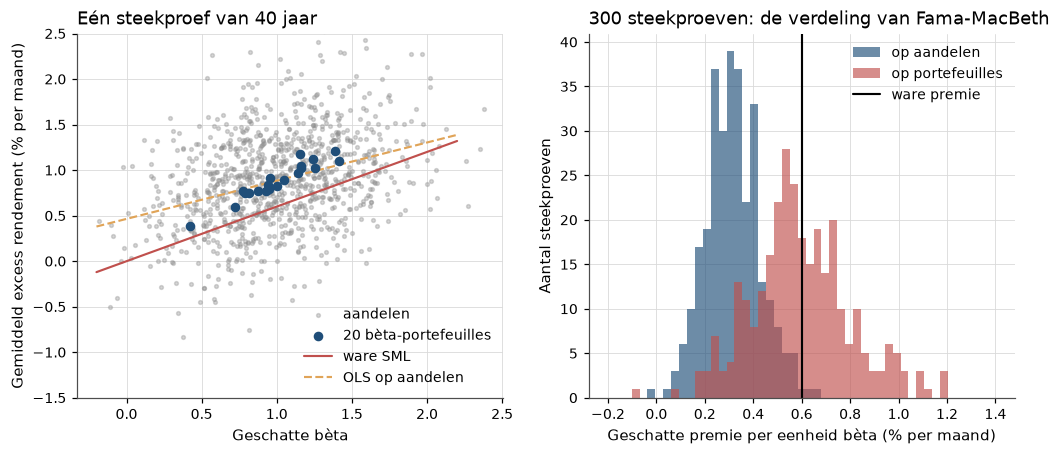

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
mean_stock, b_stock, mean_port, b_port = example
grid = np.linspace(-0.2, 2.2, 50)

ax = axes[0]
ax.scatter(b_stock, 100 * mean_stock, s=6, alpha=0.35, color=hap.plotting.COLORS[7],
           label="aandelen")
ax.scatter(b_port, 100 * mean_port, s=28, zorder=3, color=hap.plotting.COLORS[0],
           label="20 bèta-portefeuilles")
ax.plot(grid, 100 * mu_m * grid, color=hap.plotting.COLORS[1], lw=1.4, label="ware SML")
fit = np.polyfit(b_stock, mean_stock, 1)
ax.plot(grid, 100 * np.polyval(fit, grid), color=hap.plotting.COLORS[3], ls="--",
        lw=1.4, label="OLS op aandelen")
ax.set_ylim(-1.5, 2.5)
ax.set_xlabel("Geschatte bèta")
ax.set_ylabel("Gemiddeld excess rendement (% per maand)")
ax.set_title("Eén steekproef van 40 jaar")
ax.legend()

ax = axes[1]
bins = np.linspace(-0.2, 1.4, 50)
ax.hist(100 * sims["g1 aandelen"], bins=bins, alpha=0.65, label="op aandelen")
ax.hist(100 * sims["g1 portefeuilles"], bins=bins, alpha=0.65, label="op portefeuilles")
ax.axvline(100 * mu_m, color="black", lw=1.4, label="ware premie")
ax.set_xlabel("Geschatte premie per eenheid bèta (% per maand)")
ax.set_ylabel("Aantal steekproeven")
ax.set_title("300 steekproeven: de verdeling van Fama-MacBeth")
ax.legend()
plt.show()

:::{figure} #cel-capm-simulatie
:label: fig-capm-simulatie
:width: 100%

Links: in één gesimuleerde CAPM-wereld is de relatie tussen gemiddeld rendement en
geschatte bèta op individuele aandelen nauwelijks zichtbaar en systematisch te
vlak (gestreepte lijn), terwijl de twintig op bèta gesorteerde portefeuilles dicht
bij de ware lijn liggen. Rechts: over 300 steekproeven is de verdeling op aandelen
naar links verschoven (errors-in-variables), die op portefeuilles is zuiver maar
breed. Die breedte gaat met geen enkele econometrie weg: zij is de standaardfout
van het gemiddelde marktrendement.
:::

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** Fischer Black, Michael Jensen en Myron Scholes, *The Capital Asset
Pricing Model: Some Empirical Tests*, in Jensen (red.), *Studies in the Theory of
Capital Markets*, 1972 {cite}`BlackJensenScholes1972`; Eugene Fama en James
MacBeth, *Risk, Return, and Equilibrium: Empirical Tests*, Journal of Political
Economy 1973 {cite}`FamaMacBeth1973`; en de GRS-toets van
{cite:t}`GibbonsRossShanken1989`.

**Wat.** Drie gepubliceerde resultaten. (a) BJS, tabel 2 (1931–1965, 420
maanden, tien portefeuilles, jaarlijks gevormd op bèta's uit de voorgaande vijf
jaar): bèta's van 1,5614 (portefeuille 1) tot 0,4992 (portefeuille 10);
alfa's $\times 10^2$ van −0,0829 ($t = -0{,}43$) voor portefeuille 1 en 0,2012
($t = 1{,}87$) voor portefeuille 10, bij een gemiddeld excess marktrendement van
0,0142 per maand. (b) BJS, tabel 4: de cross-sectionele lijn over 1931–1965 heeft
$\hat\gamma_0 = 0{,}00359$ ($t = 6{,}52$) en $\hat\gamma_1 = 0{,}0108$, tegen
0,0142 voorspeld; in de laatste van hun vier subperiodes (4/1957–12/1965) is
$\hat\gamma_1 = -0{,}0012$. (c) Fama en MacBeth, tabel 3, panel A (1935–6/1968):
$\bar\gamma_1 = 0{,}0085$ ($t = 2{,}57$) en $\bar\gamma_0 - R^{f} = 0{,}0048$
($t = 2{,}55$), bij een gemiddelde $R_m - R^{f}$ van 0,0130 (hun tabel 4).

**Data hier.** Kenneth French Data Library via `hap.data.french`. (i) Voor
1931–1965 bouwen we zelf tien op bèta gesorteerde portefeuilles: elke december
schatten we de bèta van 149 basisactiva — de 100 portefeuilles op size en BM
(`"100_Portfolios_10x10"`) en de 49 industrieportefeuilles
(`"49_Industry_Portfolios"`), beide value-weighted — op de voorgaande 60 maanden
(minimaal 48), sorteren ze in tien groepen en houden elke groep gelijkgewogen
gedurende het volgende jaar. (ii) Voor 1963-07 tot heden gebruiken we French'
eigen decielportefeuilles op pre-ranking bèta (`"Portfolios_Formed_on_BETA"`),
die wél uit individuele aandelen zijn gevormd. (iii) De 25 size/BM-portefeuilles
(`"25_Portfolios_5x5"`), 1963-07 tot heden, voor Fama-MacBeth en GRS. Markt en
risicovrije rente uit `hap.data.market_monthly()`.

**Verschil met het origineel.** BJS sorteerden individuele aandelen (1952
verschillende fondsen over de hele periode, met minimaal 24 maanden historie; wij
eisen 48 maanden) en gebruikten een gelijkgewogen marktindex; French publiceert geen
individuele aandelen, dus onze basisactiva zijn zelf al portefeuilles, en onze
markt is de value-weighted CRSP-index. Gevolg: minder
spreiding in bèta's, vooral aan de lage kant, en basisactiva die op size zijn
gesorteerd. French' data beginnen in 1926-07, dus de eerste sortering berust op 54
maanden. Fama en MacBeth gebruikten twintig
portefeuilles van individuele aandelen en bruto rendementen; wij gebruiken
excess rendementen, zodat het CAPM $\gamma_0 = 0$ voorspelt in plaats van
$\gamma_0 = R^{f}$.

**Verwachte afwijking.** Het teken van de afwijking moet identiek zijn aan het
origineel: waar de bèta-spreiding voldoende is, ligt de geschatte SML *vlakker*
dan de lijn door de oorsprong met helling $\bar R^{e}_m$, met een intercept
boven nul en positieve alfa's voor lage-bèta- en negatieve voor
hoge-bèta-portefeuilles. Op French' bèta-decielen na 1963 moet dat ondubbelzinnig
zijn. Op 1931–1965, met portefeuilles als basisactiva en dus minder bèta-spreiding,
verwachten we het patroon zwakker.
Fama-MacBeth op de 25 size/BM-portefeuilles moet een helling geven die niet
significant positief is en een intercept dat significant boven nul ligt, en GRS
moet het CAPM op die portefeuilles verwerpen. Omdat de standaardfout van de
marktpremie over 35 jaar ruim 0,3% per maand is, zijn verschillen in helling
kleiner dan ongeveer 0,6% per maand daar niet onderscheidbaar; na 1963 is dat
ongeveer 0,3%.
```

In [10]:
market = hap_data.market_monthly()
rf_month, mkt_excess = market["RF"], market["Mkt-RF"]

base = pd.concat(
    {"sbm": hap_data.french("100_Portfolios_10x10"),
     "ind": hap_data.french("49_Industry_Portfolios")},
    axis=1,
)
base_excess = base.sub(rf_month, axis=0)


def beta_sorted_portfolios(assets, market_excess, n_groups=10, window=5, min_obs=48):
    """BJS-style portfolios: sort each December on pre-ranking beta, hold for a year.

    Portfolio 1 has the highest pre-ranking beta. Within a group, assets are
    equally weighted.
    """
    pieces = []
    for year in range(assets.index.year.min() + window - 1, assets.index.year.max()):
        history = assets.loc[f"{year - window + 1}":f"{year}"]
        history = history.loc[:, history.notna().sum() >= min_obs]
        m = market_excess.loc[history.index]
        dm = m - m.mean()
        pre_beta = history.sub(history.mean()).mul(dm, axis=0).mean() / (dm**2).mean()
        group = pd.qcut(pre_beta.rank(method="first", ascending=False), n_groups, labels=False)
        holding = assets.loc[f"{year + 1}", history.columns]
        pieces.append(holding.T.groupby(group.to_numpy()).mean().T)
    out = pd.concat(pieces)
    out.columns = [f"P{k + 1}" for k in out.columns]
    return out


bjs = beta_sorted_portfolios(base_excess, mkt_excess)
french_beta = (hap_data.french("Portfolios_Formed_on_BETA")
               .filter(regex="Lo 10|Dec|Hi 10").sub(rf_month, axis=0).dropna())
ff25 = hap_data.french("25_Portfolios_5x5").loc["1963-07":].sub(rf_month, axis=0).dropna()

pd.DataFrame(
    {"portefeuilles": [bjs.shape[1], french_beta.shape[1], ff25.shape[1]],
     "start": [p.index[0].strftime("%Y-%m") for p in (bjs, french_beta, ff25)],
     "eind": [p.index[-1].strftime("%Y-%m") for p in (bjs, french_beta, ff25)]},
    index=["BJS-stijl (eigen constructie)", "French bèta-decielen", "25 size/BM"],
)

,portefeuilles,start,eind
BJS-stijl (eigen constructie),10,1931-01,2026-07
French bèta-decielen,10,1963-07,2026-07
25 size/BM,25,1963-07,2026-07


Eerst de tijdreeksregressies [](#eq-capm-tijdreeks) per portefeuille over de
BJS-periode 1931–1965, zoals in hun tabel 2.

In [11]:
def capm_time_series(excess, market_excess):
    """Time-series CAPM regression per portfolio: beta, Jensen's alpha, mean and SE."""
    X = sm.add_constant(market_excess.loc[excess.index].rename("markt"))
    rows = {}
    for name, series in excess.items():
        fit = sm.OLS(series, X).fit()
        rows[name] = {
            "bèta": fit.params["markt"],
            "alfa (% p.m.)": 100 * fit.params["const"],
            "t(alfa)": fit.tvalues["const"],
            "gem. excess (% p.m.)": 100 * series.mean(),
            "SE gem. (% p.m.)": 100 * series.std() / np.sqrt(len(series)),
            "R2": fit.rsquared,
        }
    return pd.DataFrame(rows).T


capm_time_series(bjs.loc["1931":"1965"], mkt_excess).round(3)

,bèta,alfa (% p.m.),t(alfa),gem. excess (% p.m.),SE gem. (% p.m.),R2
P1,1.686,0.121,0.470,1.695,0.578,0.808
P2,1.529,0.111,0.517,1.539,0.517,0.830
P3,1.424,0.125,0.738,1.455,0.470,0.873
P4,1.279,0.170,1.358,1.364,0.413,0.911
P5,1.297,0.174,1.280,1.384,0.421,0.899
P6,1.203,0.110,1.060,1.233,0.385,0.929
P7,1.121,0.087,0.808,1.133,0.361,0.914
P8,1.130,0.051,0.537,1.106,0.361,0.933
P9,1.030,-0.044,-0.430,0.917,0.333,0.908
P10,0.909,0.090,1.040,0.939,0.293,0.915


Vergelijk met BJS' tabel 2. De ordening van de bèta's klopt per constructie,
maar de spreiding is veel kleiner: onze bèta's lopen van 1,69 naar 0,91, die van
BJS van 1,56 naar 0,50. Het patroon in de alfa's is
over de volledige periode niet aanwezig: bij BJS had de hoogste-bèta-portefeuille
een negatieve alfa (−0,08% per maand) en de laagste een positieve (+0,20%,
$t = 1{,}87$); bij ons zijn beide licht positief (0,12% en 0,09%) en geen van beide
significant. Dat laatste deelt onze replicatie met het origineel: ook bij BJS
hadden maar drie van de tien $t$-waarden een absolute waarde boven 1,85. De
standaardfouten van de gemiddelden, 0,3 tot 0,6% per maand, zijn van dezelfde
orde als de verschillen tussen de portefeuilles — motief 1, per portefeuille.

Nu de cross-sectie en GRS. Het CAPM voorspelt dat de helling $\gamma_1$ gelijk is
aan de marktpremie op dezelfde rij, en dat $\gamma_0 = 0$.

In [12]:
def sml_test(excess, market_excess, label):
    """Fama-MacBeth with full-period betas, Shanken t-values, and the GRS test."""
    f = market_excess.loc[excess.index]
    betas = excess.apply(lambda col: col.cov(f) / f.var())
    fm = hap.stats.fama_macbeth(excess, {"beta": betas.to_frame().T}, lags=0)
    gammas = fm.attrs["gammas"].to_numpy()
    _, se_sh = shanken_se(gammas, f.loc[fm.attrs["gammas"].index].to_numpy())
    grs = hap.stats.grs_test(excess, f.to_frame())
    return pd.Series(
        {
            "maanden": len(excess),
            "bèta min": betas.min(), "bèta max": betas.max(),
            "gamma_0 (% p.m.)": 100 * fm.loc["const", "estimate"],
            "t(gamma_0)": fm.loc["const", "tstat"],
            "gamma_1 (% p.m.)": 100 * fm.loc["beta", "estimate"],
            "t(gamma_1) FM": fm.loc["beta", "tstat"],
            "t(gamma_1) Shanken": fm.loc["beta", "estimate"] / se_sh[1],
            "marktpremie (% p.m.)": 100 * f.mean(),
            "SE marktpremie": 100 * f.std() / np.sqrt(len(f)),
            "gamma_1 / premie": fm.loc["beta", "estimate"] / f.mean(),
            "GRS": grs["grs"], "p(GRS)": grs["pvalue"],
        },
        name=label,
    )


samples = [
    (bjs, "1931-01", "1965-12", "BJS-stijl 1931-1965"),
    (bjs, "1931-01", "1939-09", "  subperiode 1931-01 - 1939-09"),
    (bjs, "1939-10", "1948-06", "  subperiode 1939-10 - 1948-06"),
    (bjs, "1948-07", "1957-03", "  subperiode 1948-07 - 1957-03"),
    (bjs, "1957-04", "1965-12", "  subperiode 1957-04 - 1965-12"),
    (bjs, "1935-01", "1968-06", "BJS-stijl, FM-periode 1935-1968"),
    (bjs, "1966-01", "2026-12", "BJS-stijl 1966-heden"),
    (french_beta, "1963-07", "2026-12", "French bèta-decielen 1963-heden"),
    (ff25, "1963-07", "2026-12", "25 size/BM 1963-heden"),
]
sml_table = pd.DataFrame(
    [sml_test(panel.loc[a:b], mkt_excess, label) for panel, a, b, label in samples]
)
sml_table.round(3)

,maanden,bèta min,bèta max,gamma_0 (% p.m.),t(gamma_0),gamma_1 (% p.m.),t(gamma_1) FM,t(gamma_1) Shanken,marktpremie (% p.m.),SE marktpremie,gamma_1 / premie,GRS,p(GRS)
BJS-stijl 1931-1965,420.0,0.909,1.686,-0.064,-0.193,1.063,2.381,2.361,0.934,0.308,1.138,0.589,0.823
subperiode 1931-01 - 1939-09,105.0,0.935,1.769,-1.820,-1.882,2.674,1.899,1.865,0.843,1.056,3.172,0.701,0.722
subperiode 1939-10 - 1948-06,105.0,0.899,1.727,-0.386,-0.643,1.362,1.854,1.793,0.838,0.439,1.625,1.347,0.217
subperiode 1948-07 - 1957-03,105.0,0.659,1.235,0.819,2.391,0.330,0.623,0.619,1.245,0.337,0.265,1.928,0.051
subperiode 1957-04 - 1965-12,105.0,0.927,1.266,1.792,3.410,-0.762,-1.286,-1.258,0.809,0.327,-0.942,2.056,0.036
"BJS-stijl, FM-periode 1935-1968",402.0,0.833,1.624,0.270,0.920,0.779,2.102,2.080,0.956,0.226,0.815,2.187,0.018
BJS-stijl 1966-heden,727.0,0.766,1.417,0.790,3.331,-0.069,-0.236,-0.236,0.585,0.168,-0.117,2.520,0.006
French bèta-decielen 1963-heden,757.0,0.594,1.604,0.384,1.972,0.276,1.097,1.095,0.599,0.162,0.460,2.025,0.028
25 size/BM 1963-heden,757.0,0.860,1.417,1.164,3.149,-0.370,-0.930,-0.927,0.599,0.162,-0.617,4.196,0.000


Over de volledige BJS-periode ligt onze
geschatte lijn *niet* vlakker dan het CAPM: helling 1,06% per maand tegen een
marktpremie van 0,93%, intercept −0,06%. BJS vonden op individuele aandelen 1,08%
tegen 1,42% en een intercept van 0,36% met $t = 6{,}52$. De subperiodes laten zien
waar het verschil vandaan komt. In 1931–1939 is onze helling 2,67% per maand
tegen een premie van 0,84% en het intercept −1,82%; BJS vonden in die subperiode
eveneens een te steile lijn (3,04% tegen 2,20%) en een negatief intercept
(−0,80%). De jaren dertig belonen hoge bèta's ruim, en omdat onze basisactiva op
size zijn gesorteerd, vallen hoge bèta en kleine ondernemingen in die jaren samen.
In de drie latere subperiodes loopt ons patroon vrijwel gelijk op met dat van BJS:
de helling daalt van 1,36 via 0,33 naar −0,76% per maand (BJS: 1,07, 0,33 en
−0,12), het intercept stijgt van −0,39 via 0,82 naar 1,79% (BJS: 0,44, 0,78 en
1,02), en in 1957–1965 heeft de lijn bij beide het verkeerde teken. Het teken van
de afwijking is dus identiek zodra de jaren dertig buiten beschouwing blijven;
over 1931–1965 als geheel domineert bij ons de subperiode waarin de standaardfout
van de marktpremie ruim 1% per maand is.

Na 1963 is het beeld eenduidig. Op French' bèta-decielen, gevormd uit individuele
aandelen zoals bij BJS, is de helling 0,28% per maand tegen een marktpremie van
0,60%, met een intercept van 0,38%: minder dan de helft van de voorspelde beloning
per eenheid bèta. Op onze eigen constructie na 1966 is de helling −0,07% en het
intercept 0,79% ($t = 3{,}33$); op de 25 size/BM-portefeuilles is de helling
−0,37% en het intercept 1,16% per maand ($t = 3{,}15$). In geen van de drie is
de helling significant positief, terwijl de marktpremie zelf met een standaardfout
van 0,16% per maand wél significant is. De GRS-toets verwerpt het CAPM op alle
drie op 5%, op de 25 size/BM-portefeuilles overtuigend ($\mathrm{GRS} = 4{,}20$,
$p < 0{,}001$); op onze BJS-portefeuilles over 1931–1965 verwerpt zij het niet
($p = 0{,}82$), net zoals {cite:t}`GibbonsRossShanken1989` het op de BJS-data niet
verwierpen ($F = 0{,}96$, $p = 0{,}48$).

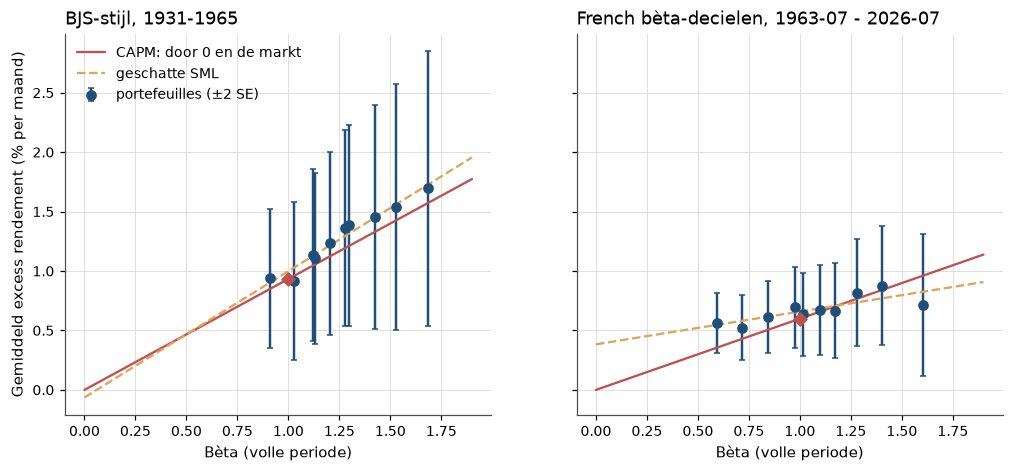

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
panels = [(bjs.loc["1931":"1965"], "BJS-stijl, 1931-1965"),
          (french_beta, f"French bèta-decielen, 1963-07 - {french_beta.index[-1]:%Y-%m}")]
for ax, (panel, title) in zip(axes, panels):
    table = capm_time_series(panel, mkt_excess)
    premium = 100 * mkt_excess.loc[panel.index].mean()
    grid = np.linspace(0, 1.9, 20)
    slope, intercept = np.polyfit(table["bèta"], table["gem. excess (% p.m.)"], 1)
    ax.errorbar(table["bèta"], table["gem. excess (% p.m.)"],
                yerr=2 * table["SE gem. (% p.m.)"], fmt="o", capsize=2,
                color=hap.plotting.COLORS[0], label="portefeuilles ($\\pm$2 SE)")
    ax.plot(grid, premium * grid, color=hap.plotting.COLORS[1], lw=1.5,
            label="CAPM: door 0 en de markt")
    ax.plot(grid, intercept + slope * grid, color=hap.plotting.COLORS[3], ls="--", lw=1.5,
            label="geschatte SML")
    ax.scatter([1.0], [premium], marker="D", zorder=3, color=hap.plotting.COLORS[1])
    ax.set_title(title)
    ax.set_xlabel("Bèta (volle periode)")
axes[0].set_ylabel("Gemiddeld excess rendement (% per maand)")
axes[0].legend(loc="upper left")
plt.show()

:::{figure} #cel-capm-sml-data
:label: fig-capm-sml-data
:width: 100%

Gemiddelde excess rendementen tegen bèta, met twee standaardfouten. Links,
1931–1965 in onze eigen BJS-constructie: de portefeuilles liggen rond de CAPM-lijn
en de geschatte lijn is even steil; de spreiding in bèta (0,91 tot 1,69) is te
klein en de onzekerheid per punt te groot om veel te onderscheiden. Rechts,
French' bèta-decielen na 1963: de geschatte lijn is ongeveer half zo steil als de
lijn door de oorsprong en de markt, de laagste-bèta-portefeuille ligt erboven en de
hoogste eronder.
:::

Tot slot Fama-MacBeth in de oorspronkelijke vorm, met bèta's die elke maand
opnieuw worden geschat uit de voorgaande 60 maanden.

In [14]:
def rolling_fama_macbeth(excess, market_excess, window=60):
    """Fama-MacBeth with betas estimated on the previous `window` months."""
    f = market_excess.loc[excess.index]
    betas = excess.rolling(window).cov(f).div(f.rolling(window).var(), axis=0).shift(1)
    fm = hap.stats.fama_macbeth(excess, {"beta": betas}, lags=0)
    out = fm[["estimate", "se", "tstat", "n_periods"]].assign(
        estimate=lambda d: 100 * d["estimate"], se=lambda d: 100 * d["se"])
    out.attrs = {}  # drop the per-period gammas so pd.concat does not compare them
    return out


pd.concat(
    {"BJS-stijl 1936-1968": rolling_fama_macbeth(bjs.loc["1930-01":"1968-06"], mkt_excess),
     "25 size/BM 1963-heden": rolling_fama_macbeth(ff25, mkt_excess)}
).round(3)

estimate     se  tstat  n_periods
BJS-stijl 1936-1968   const     0.132  0.320  0.411        390
                      beta      0.804  0.381  2.108        390
25 size/BM 1963-heden const     0.951  0.247  3.854        697
                      beta     -0.238  0.288 -0.828        697

Over de periode van Fama en MacBeth is de helling positief en significant maar
vlakker dan voorspeld: 0,78% tegen een premie van 0,96% met vaste bèta's (tabel
hierboven), 0,80% ($t = 2{,}11$) met rollende bèta's over 1936–6/1968. Fama en
MacBeth vonden 0,85% tegen 1,30% ($t = 2{,}57$) en een intercept van 0,48% boven
de risicovrije rente ($t = 2{,}55$); ons intercept is 0,27% respectievelijk 0,13%
en niet significant, wat past bij de size-sortering van onze basisactiva. Op de
25 size/BM-portefeuilles na 1963 is de helling −0,24% ($t = -0{,}83$) en het
intercept 0,95% per maand ($t = 3{,}85$): ruim 11% per jaar aan gemiddeld
rendement dat niet door bèta wordt verklaard. Dat de 25 portefeuilles sterk
verschillen in gemiddeld rendement staat buiten kijf; dat bèta dat verschil niet
verklaart, is het startpunt van [](#04-18-fama-french).

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** Het CAPM heeft het vak een taal gegeven die het
nooit meer is kwijtgeraakt. Het scheidde risico dat beloond wordt van risico dat
niet beloond wordt, en gaf voor het eerst een getal — de bèta — waarmee dat
onderscheid te meten is. Het maakte van de marktportefeuille de natuurlijke
maatstaf, en daarmee van het indexfonds de natuurlijke belegging. Het gaf bedrijven
een kostenvoet van vermogen en beleggers met de alfa van {cite:t}`Jensen1968` een
maatstaf voor fondsbeheerders. En de bèta is
niet waardeloos: in de tijdreeks verklaart hij 60 tot 90% van de variantie van een
gespreide portefeuille, zoals de $R^2$ in de tabel hierboven laten zien. Wat hij
niet verklaart, is het *gemiddelde*.

**Waar het breekt.** De security market line is te vlak. Op French'
decielportefeuilles op bèta levert een eenheid bèta sinds 1963 0,28% per maand op
tegen de 0,60% die het CAPM voorspelt, en de portefeuille met de laagste bèta heeft
een alfa van 0,21% per maand ($t = 2{,}53$). BJS zagen het begin ervan in hun
laatste subperiode, en na 1963 is van een significante beloning voor bèta op geen
van de drie verzamelingen portefeuilles iets over. De simulatie laat
zien dat dit op portefeuilles geen artefact van errors-in-variables kan zijn.

**Risico of vergissing?** Ook hier bestaan twee lezingen van hetzelfde feit. De
eerste blijft binnen rationele prijsvorming. Het zero-beta-model van
{cite:t}`Black1972` voorspelt precies een vlakke lijn met een intercept boven de
risicovrije rente zodra lenen beperkt of duur is: beleggers die meer risico willen,
kopen hoge-bèta-aandelen in plaats van hefboom en betalen daarvoor in evenwicht met
een lager rendement. Dat is geen vergissing maar de prijs van een echte
beperking; {cite:t}`FrazziniPedersen2014` bouwden er een strategie op die met
hefboom lage-bèta-aandelen koopt. Een andere rationele uitweg: de index is niet de
markt, of er zijn meer beprijsde risico's. De andere lezing ziet mispricing. Beheerders die aan een index worden
afgemeten mijden lage-bèta-aandelen, omdat die hun *tracking error* (de afwijking
van het rendement ten opzichte van de index) vergroten; en de arbitrageurs die de
prijs zouden moeten rechttrekken, hebben daarvoor hefboom nodig — precies wat
beperkt is. In die lezing zit de prijs ernaast en blijft ze ernaast zitten, omdat
corrigeren riskant en duur is. Beide lezingen voorspellen een vlakke lijn; wat ze
zou scheiden — strakkere leenbeperkingen tegenover omslaand sentiment — beweegt in
de data vaak samen. Voor een belegger is het de vraag van Santa-Clara: is de
premie van lage-bèta-aandelen een beloning voor het dragen van een beprijsde
beperking, of een vermeend inzicht dat verdwijnt zodra genoeg mensen het kennen?

**Wat er daarna kwam.** Het CAPM was niet alleen een theorie om te toetsen maar
ook een instrument om mee te rekenen: Black en Scholes gebruikten het in 1973 in
een van hun twee afleidingen van de prijs van een optie, en daarmee begon het
tweede grote project van het Chicago–MIT-decennium, [](#02-09-black-scholes). Dat
een toets van het CAPM eigenlijk een toets van de gekozen index is, wordt het punt
van [](#03-14-roll); dat andere kenmerken dan bèta het gemiddelde rendement
verklaren, dat van [](#04-18-fama-french).

## Oefeningen

:::{exercise}
:label: ex-capm-1

**Errors-in-variables in getallen.** Neem de calibratie uit de simulatie:
$\sigma_\beta = 0{,}30$, $\bar\beta = 1$, $\sigma_\varepsilon = 10\%$ en
$\sigma_m = 4{,}5\%$ per maand, $\gamma_1 = 0{,}6\%$ per maand en $T = 60$
maanden voor de bèta-schatting.

1. Leid af dat de OLS-bèta uit $T$ maanden, gegeven de factorrealisaties, een
   meetfout heeft met variantie
   $\sigma^2_\varepsilon/\sum_t (f_t - \bar f)^2 \approx \sigma^2_\varepsilon/(T\sigma_m^2)$,
   en bereken $\kappa$, de verwachte helling en de bias in het intercept uit
   [](#eq-capm-eiv).
2. Hoeveel aandelen $n$ moet een portefeuille minimaal bevatten om
   $\kappa \geq 0{,}95$ te halen als de spreiding in ware bèta's over
   portefeuilles 0,30 blijft? En als zij, zoals in de simulatie, daalt tot 0,22?
3. Vergelijk (1) met de gesimuleerde gemiddelden in de simulatietabel.
:::

:::{solution} ex-capm-1
:class: dropdown

**(1)** Met $R^{e}_{i,t} = \beta_i f_t + \varepsilon_{i,t}$ is
$\hat\beta_i - \beta_i = \sum_t (f_t - \bar f)\varepsilon_{i,t} / \sum_t (f_t - \bar f)^2$.
Gegeven de $f_t$ is dat een lineaire combinatie van onafhankelijke
$\varepsilon$'s met variantie
$\sigma^2_\varepsilon / \sum_t (f_t-\bar f)^2$, en
$\sum_t (f_t - \bar f)^2 \approx T\sigma_m^2$. Dus
$\sigma_u^2 = 0{,}01/(60 \cdot 0{,}002025) = 0{,}0823$ en
$\kappa = 0{,}09/(0{,}09 + 0{,}0823) = 0{,}522$: verwachte helling
$0{,}522 \cdot 0{,}6 = 0{,}313\%$ en intercept-bias
$(1 - 0{,}522)\cdot 0{,}6 \cdot 1 = 0{,}287\%$ per maand.

**(2)** Een portefeuille van $n$ aandelen heeft meetfoutvariantie ongeveer
$\sigma_u^2/n$, en $\kappa \geq 0{,}95$ betekent
$\sigma_u^2/n \leq \sigma_\beta^2/19$, dus $n \geq 19\sigma_u^2/\sigma_\beta^2$:
$n \geq 17{,}4$, dus 18 aandelen, bij spreiding 0,30, en $n \geq 32{,}3$, dus
33, bij spreiding 0,22.

In [15]:
sigma_u2 = sd_eps**2 / (T_est * sd_m**2)
eiv = {}
for label, sd_beta in [("spreiding 0,30", 0.30), ("spreiding 0,22", 0.22)]:
    kappa = sd_beta**2 / (sd_beta**2 + sigma_u2)
    eiv[label] = {
        "sigma_u^2": sigma_u2,
        "kappa (n = 1)": kappa,
        "helling (% p.m.)": 100 * kappa * mu_m,
        "intercept-bias (% p.m.)": 100 * (1 - kappa) * mu_m,
        "minimale n": int(np.ceil(19 * sigma_u2 / sd_beta**2)),
    }
pd.DataFrame(eiv).T.assign(
    **{"gesimuleerde helling": 100 * sims["g1 aandelen"].mean(),
       "gesimuleerd intercept": 100 * sims["g0 aandelen"].mean()}
).round(3)

,sigma_u^2,kappa (n = 1),helling (% p.m.),intercept-bias (% p.m.),minimale n,gesimuleerde helling,gesimuleerd intercept
"spreiding 0,30",0.082,0.522,0.313,0.287,18.0,0.316,0.298
"spreiding 0,22",0.082,0.370,0.222,0.378,33.0,0.316,0.298


**(3)** De simulatie geeft een helling van 0,316% en een intercept van 0,298% per
maand, tegen 0,313% en 0,287% uit de formule. De oefening laat zien dat een paar dozijn aandelen
per portefeuille genoeg is om de meetfout vrijwel weg te werken; wat daarna
overblijft, is de onzekerheid over de marktpremie zelf, en die krimpt met $T$ en
niet met $n$.
:::

:::{exercise}
:label: ex-capm-2

**De keuze van basisactiva.** Herhaal de BJS-stijlreplicatie over 1931–1965 en de
vier subperiodes, maar gebruik als basisactiva alleen de 49
industrieportefeuilles (`base_excess["ind"]`).

1. Rapporteer de bèta-spreiding, $\gamma_0$, $\gamma_1$ en de verhouding van
   $\gamma_1$ tot de marktpremie.
2. Is de lijn over 1931–1965 nu vlakker dan het CAPM voorspelt? Wat verandert er
   in de jaren dertig?
3. Wat leert dit over replicaties waarin de onderzoeker de basisactiva kiest?
:::

:::{solution} ex-capm-2
:class: dropdown

In [16]:
bjs_industries = beta_sorted_portfolios(base_excess["ind"], mkt_excess)
pd.DataFrame(
    [sml_test(bjs_industries.loc[a:b], mkt_excess, label) for _, a, b, label in samples[:5]]
)[["bèta min", "bèta max", "gamma_0 (% p.m.)", "t(gamma_0)", "gamma_1 (% p.m.)",
   "t(gamma_1) FM", "marktpremie (% p.m.)", "gamma_1 / premie"]].round(3)

,bèta min,bèta max,gamma_0 (% p.m.),t(gamma_0),gamma_1 (% p.m.),t(gamma_1) FM,marktpremie (% p.m.),gamma_1 / premie
BJS-stijl 1931-1965,0.737,1.385,0.291,1.051,0.744,1.852,0.934,0.797
subperiode 1931-01 - 1939-09,0.735,1.401,-1.141,-1.424,2.046,1.596,0.843,2.427
subperiode 1939-10 - 1948-06,0.839,1.470,0.311,0.652,0.745,1.177,0.838,0.889
subperiode 1948-07 - 1957-03,0.527,1.226,0.446,1.683,0.795,1.828,1.245,0.638
subperiode 1957-04 - 1965-12,0.816,1.242,1.853,3.325,-0.831,-1.345,0.809,-1.028


**(1) en (2)** Met alleen industrieën reikt de bèta-spreiding verder naar
beneden (0,74 in plaats van 0,91), en de lijn over 1931–1965 is nu wél vlakker dan
het CAPM voorspelt: de helling is 0,74% per maand tegen een premie van 0,93%, een
verhouding van 0,80, en het intercept is positief, 0,29% per maand — het teken
van BJS, al is het met $t = 1{,}05$ niet significant. In 1931–1939 blijft de lijn
te steil (2,43 tegen 3,17 bij de size/BM-basis); daarna daalt de verhouding via
0,89 en 0,64 naar −1,03, zoals bij BJS.

**(3)** Dezelfde methode op dezelfde maanden geeft over 1931–1965 een ander
antwoord, afhankelijk van de vraag of de basisactiva op size zijn gesorteerd. Zodra
bèta en een ander kenmerk samenvallen, meet een sortering op bèta beide. Precies daarom sorteerden Fama en French in 1992 eerst op size
en daarbinnen op bèta — het begin van [](#04-18-fama-french).
:::

:::{exercise}
:label: ex-capm-3

**De meetkunde van GRS.** Neem de 25 size/BM-portefeuilles, 1963-07 tot heden.

1. Bereken met ML-momenten de Sharpe-ratio $\hat S_m$ van de markt en de maximale
   Sharpe-ratio $\hat S_q$ van de 25 portefeuilles samen met de markt, per maand
   en per jaar.
2. Verifieer numeriek dat
   $\hat{\boldsymbol{\alpha}}'\hat{\boldsymbol{\Sigma}}^{-1}\hat{\boldsymbol{\alpha}} = \hat S_q^2 - \hat S_m^2$,
   bereken GRS met [](#eq-capm-grs) en vergelijk met `hap.stats.grs_test`.
3. Hoeveel van $\hat S_q^2 - \hat S_m^2$ zou u puur door schattingsfout
   verwachten (gebruik $\E[\hat S^2] \approx S^2 + N/T$ uit
   [](#01-04-markowitz))? Wat betekent dat voor de verwerping?
:::

:::{solution} ex-capm-3
:class: dropdown

In [17]:
f25 = mkt_excess.loc[ff25.index]
X25 = np.column_stack([np.ones(len(f25)), f25.to_numpy()])
coef = np.linalg.lstsq(X25, ff25.to_numpy(), rcond=None)[0]
alpha_hat = coef[0]
resid = ff25.to_numpy() - X25 @ coef
T25, N25 = ff25.shape
Sigma_ml = resid.T @ resid / T25

assets = np.column_stack([f25.to_numpy(), ff25.to_numpy()])
mean_all = assets.mean(axis=0)
S2_q = mean_all @ np.linalg.solve(np.cov(assets, rowvar=False, bias=True), mean_all)
S2_m = f25.mean() ** 2 / f25.var(ddof=0)
quad = alpha_hat @ np.linalg.solve(Sigma_ml, alpha_hat)

pd.Series(
    {
        "S_m (p.m.)": np.sqrt(S2_m), "S_q (p.m.)": np.sqrt(S2_q),
        "S_m (p.j.)": np.sqrt(12 * S2_m), "S_q (p.j.)": np.sqrt(12 * S2_q),
        "alpha' Sigma^-1 alpha": quad, "S_q^2 - S_m^2": S2_q - S2_m,
        "verwachte bias N/T": N25 / T25,
        "GRS met de hand": (T25 - N25 - 1) / N25 * quad / (1 + S2_m),
        "GRS hap.stats": hap.stats.grs_test(ff25, f25.to_frame())["grs"],
    }
).round(4)

S_m (p.m.)               0.1344
S_q (p.m.)               0.4052
S_m (p.j.)               0.4656
S_q (p.j.)               1.4036
alpha' Sigma^-1 alpha    0.1461
S_q^2 - S_m^2            0.1461
verwachte bias N/T       0.0330
GRS met de hand          4.1963
GRS hap.stats            4.1963
dtype: float64

**(1) en (2)** De identiteit klopt tot op de getoonde decimalen, en de
handberekening geeft exact de GRS-waarde van `hap.stats.grs_test`, 4,196. De markt
haalt een Sharpe-ratio van 0,134 per maand (0,47 per jaar); de beste combinatie
van de 25 portefeuilles en de markt haalt in-sample 0,405 per maand (1,40 per
jaar), driemaal zoveel.

**(3)** Met $N/T = 25/757 \approx 0{,}033$ verklaart schattingsfout maar een klein
deel van $\hat S_q^2 - \hat S_m^2 = 0{,}146$. GRS verwerpt dus niet omdat de
optimalisator ruis vindt, maar omdat de 25 portefeuilles een richting bevatten —
klein en waarde tegenover groot en groei — die de markt niet beprijst. Dat is de vorm waarin {prf:ref}`prop-capm-beta` faalt: de index
ligt niet op de frontier van deze activa.
:::

<!-- Referenties verschijnen automatisch onderaan de pagina. -->